# Длина текстов при трёх определениях `meso`

Сравниваются первые предложение, три предложения и полный первый абзац **тех же выбранных секционных лидов**. Здесь измеряется только длина и доступность примеров для усечения; классификатор не обучается. `macro` и `micro` остаются теми же текстами во всех сценариях.

In [ ]:
from pathlib import Path
import gzip
import io
import json
import re
import sys
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

ROOT = Path.cwd()
PROBE = ROOT
sys.path.insert(0, str(PROBE / 'src'))
from dataset import parse_document, first_sentence, DATA_URL

SPANS_PATH = PROBE / 'data/spans/spans.jsonl'
MESO_CACHE = PROBE / 'data/spans/meso_variants.jsonl'
RAW_PATH = PROBE / 'data/raw/pes2o.json.gz'
MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
SCENARIOS = ['first_sentence', 'first_three_sentences', 'first_paragraph']
LABELS = ['macro', 'meso', 'micro']
TARGETS = [24, 32, 64, 100, 150]
SELECTED_LENGTH = 24
sns.set_theme(style='whitegrid', context='notebook')

TypeError: unsupported operand type(s) for /: 'str' and 'str'

## Восстановление начального абзаца

В `spans.jsonl` для `meso` сохранено только первое предложение. Файл `meso_variants.jsonl` содержит соответствующие первые абзацы из исходного peS2o. Если кэша нет или изменится набор `span_id`, ячейка ниже восстановит его из исходного validation shard. При совпадении первого предложения с **несколькими разными абзацами** вариант считается неоднозначным и исключается из всех трёх сценариев.

In [ ]:
spans = [json.loads(line) for line in SPANS_PATH.read_text(encoding='utf-8').splitlines()]
meso_rows = [row for row in spans if row['label'] == 'meso']


def first_three_sentences(paragraph):
    # Та же граница предложения, что и в dataset.py / first_sentence.
    return ' '.join(re.split(r'(?<=[.!?])\s+(?=[A-Z0-9])', paragraph, maxsplit=3)[:3])


def rebuild_meso_cache():
    by_paper = {}
    for row in meso_rows:
        by_paper.setdefault(row['paper_id'], []).append(row)
    found = {}
    if RAW_PATH.exists():
        stream = gzip.open(RAW_PATH, 'rt', encoding='utf-8')
    else:
        response = urllib.request.urlopen(DATA_URL)
        stream = io.TextIOWrapper(gzip.GzipFile(fileobj=response), encoding='utf-8')
    with stream:
        for line in stream:
            record = json.loads(line)
            paper_id = str(record['id'])
            if paper_id not in by_paper:
                continue
            _, _, sections = parse_document(record.get('text', ''))
            for row in by_paper[paper_id]:
                matches = [section['paragraphs'][0] for section in sections
                           if section['name'] == row['section_name'] and section['paragraphs']
                           and first_sentence(section['paragraphs'][0]) == row['text']]
                unique = list(dict.fromkeys(matches))
                if not unique:
                    raise ValueError(f"Не найден исходный абзац: {row['span_id']}")
                paragraph = unique[0] if len(unique) == 1 else None
                found[row['span_id']] = {
                    'span_id': row['span_id'], 'paper_id': paper_id,
                    'section_name': row['section_name'], 'domain': row['domain'],
                    'first_sentence': row['text'],
                    'first_three_sentences': first_three_sentences(paragraph) if paragraph else None,
                    'first_paragraph': paragraph,
                    'matching_paragraphs': len(matches),
                    'ambiguous': len(unique) > 1,
                }
    if set(found) != {row['span_id'] for row in meso_rows}:
        raise ValueError('Не все выбранные meso удалось восстановить')
    with MESO_CACHE.open('w', encoding='utf-8') as stream:
        for row in meso_rows:
            stream.write(json.dumps(found[row['span_id']], ensure_ascii=False) + '\n')
    return [found[row['span_id']] for row in meso_rows]


if MESO_CACHE.exists():
    cached = [json.loads(line) for line in MESO_CACHE.read_text(encoding='utf-8').splitlines()]
else:
    cached = []
if {row['span_id'] for row in cached} != {row['span_id'] for row in meso_rows}:
    cached = rebuild_meso_cache()

ambiguous = [row for row in cached if row['ambiguous']]
meso_text = {row['span_id']: row for row in cached if not row['ambiguous']}
assert all(meso_text[row['span_id']]['first_sentence'] == row['text']
           for row in meso_rows if row['span_id'] in meso_text)
print(f"Выбранных meso: {len(meso_rows)}; однозначно сопоставлены: {len(meso_text)}; исключены: {len(ambiguous)}")
display(pd.DataFrame(ambiguous)[['span_id', 'paper_id', 'section_name', 'matching_paragraphs']])

Выбранных meso: 500; однозначно сопоставлены: 497; исключены: 3


,span_id,paper_id,section_name,matching_paragraphs
0,dc0f42098dd054c9,254669672,The Workbench,3
1,c8a18d03a36cec17,254776044,Ablation Study,2
2,69f8516e9775f2a7,254317440,Statistical Methods,2


## Одинаковые примеры во всех сценариях

Во всех трёх вариантах остаются те же `macro` и `micro`, а для `meso` меняется только граница выбранного текста. Длину считаем в токенах MiniLM **без специальных токенов**, как в эксперименте с контролем длины.

In [ ]:
paired = [row for row in spans if row['label'] != 'meso' or row['span_id'] in meso_text]
frames = []
for scenario in SCENARIOS:
    frame = pd.DataFrame(paired).copy()
    if scenario != 'first_sentence':
        mask = frame['label'].eq('meso')
        frame.loc[mask, 'text'] = frame.loc[mask, 'span_id'].map(
            lambda span_id: meso_text[span_id][scenario]
        )
    frame['scenario'] = scenario
    frames.append(frame)
lengths = pd.concat(frames, ignore_index=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, local_files_only=True)
tokenizer.model_max_length = 10**9
unique_texts = lengths['text'].drop_duplicates().tolist()
encoded = tokenizer(unique_texts, add_special_tokens=False, truncation=False,
                    return_attention_mask=False, return_token_type_ids=False)['input_ids']
token_counts = dict(zip(unique_texts, map(len, encoded)))
lengths['model_token_count'] = lengths['text'].map(token_counts)
assert lengths.groupby('scenario')['span_id'].nunique().eq(len(paired)).all()
print(f"Примеров на сценарий: {len(paired)}; уникальных статей: {len({row['paper_id'] for row in paired})}")
display(pd.crosstab([lengths['scenario'], lengths['domain']], lengths['label']).reindex(columns=LABELS))

Примеров на сценарий: 1497; уникальных статей: 589


label                         macro  meso  micro
scenario              domain                    
first_paragraph       cv        250   248    250
                      nlp       250   249    250
first_sentence        cv        250   248    250
                      nlp       250   249    250
first_three_sentences cv        250   248    250
                      nlp       250   249    250

## Распределение длин

Квантили показывают, как изменение определения `meso` сдвигает длину. Строки `macro` и `micro` служат неизменной точкой сравнения.

In [ ]:
summary = (
    lengths.groupby(['scenario', 'label'], observed=True)['model_token_count']
    .agg(n='size', min='min', p05=lambda s: s.quantile(.05),
         p25=lambda s: s.quantile(.25), median='median',
         p75=lambda s: s.quantile(.75), p95=lambda s: s.quantile(.95), max='max')
    .round(1)
)
display(summary)

n  min   p05   p25  median    p75    p95   max
scenario              label                                                  
first_paragraph       macro  500    6  11.0  55.2   152.0  229.2  384.1  1237
                      meso   497   15  31.0  83.0   142.0  220.0  395.6  1953
                      micro  500   35  48.0  82.0   140.0  205.2  433.0  1252
first_sentence        macro  500    6  11.0  55.2   152.0  229.2  384.1  1237
                      meso   497   11  14.0  21.0    29.0   40.0   65.0   629
                      micro  500   35  48.0  82.0   140.0  205.2  433.0  1252
first_three_sentences macro  500    6  11.0  55.2   152.0  229.2  384.1  1237
                      meso   497   15  30.0  60.0    81.0  105.0  150.0   738
                      micro  500   35  48.0  82.0   140.0  205.2  433.0  1252

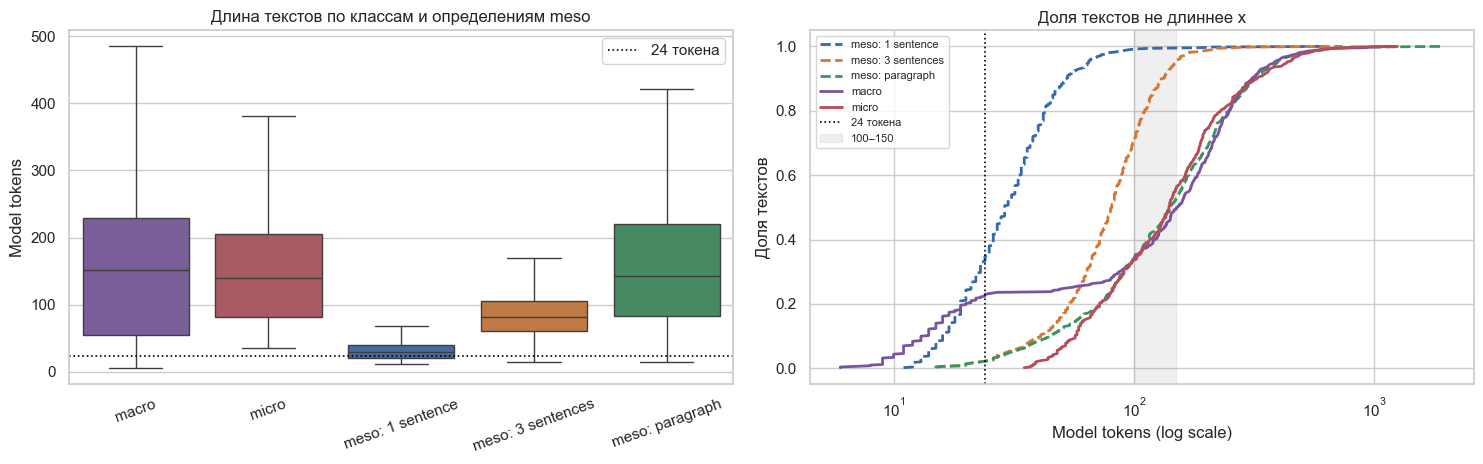

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
meso_lengths = lengths[lengths['label'] == 'meso']
reference = lengths[(lengths['scenario'] == 'first_sentence') & (lengths['label'].isin(['macro', 'micro']))]
plot_rows = []
for label, title in [('macro', 'macro'), ('micro', 'micro'),
                     ('meso', 'meso: 1 sentence'), ('meso', 'meso: 3 sentences'),
                     ('meso', 'meso: paragraph')]:
    if label != 'meso':
        subset = reference[reference['label'] == label].copy()
    else:
        scenario = {'meso: 1 sentence': 'first_sentence',
                    'meso: 3 sentences': 'first_three_sentences',
                    'meso: paragraph': 'first_paragraph'}[title]
        subset = meso_lengths[meso_lengths['scenario'] == scenario].copy()
    subset['display_group'] = title
    plot_rows.append(subset)
plot_df = pd.concat(plot_rows, ignore_index=True)
order = ['macro', 'micro', 'meso: 1 sentence', 'meso: 3 sentences', 'meso: paragraph']
palette = {'macro': '#7954a3', 'meso: 1 sentence': '#3568ad',
           'meso: 3 sentences': '#d47732', 'meso: paragraph': '#3b9460',
           'micro': '#b74d58'}
sns.boxplot(data=plot_df, x='display_group', y='model_token_count',
            order=order, palette=palette, hue='display_group',
            legend=False, showfliers=False, ax=axes[0])
axes[0].axhline(SELECTED_LENGTH, color='black', ls=':', lw=1.2, label='24 токена')
axes[0].set(title='Длина текстов по классам и определениям meso',
            xlabel='', ylabel='Model tokens')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

for scenario, title in [('first_sentence', 'meso: 1 sentence'),
                        ('first_three_sentences', 'meso: 3 sentences'),
                        ('first_paragraph', 'meso: paragraph')]:
    values = np.sort(meso_lengths.loc[meso_lengths['scenario'] == scenario, 'model_token_count'].to_numpy())
    axes[1].plot(values, np.arange(1, len(values) + 1) / len(values),
                 label=title, color=palette[title], lw=2, ls='--')
for label in ['macro', 'micro']:
    values = np.sort(reference.loc[reference['label'] == label, 'model_token_count'].to_numpy())
    axes[1].plot(values, np.arange(1, len(values) + 1) / len(values),
                 label=label, color=palette[label], lw=2, ls='-')
axes[1].axvline(SELECTED_LENGTH, color='black', ls=':', lw=1.2, label='24 токена')
axes[1].axvspan(100, 150, color='grey', alpha=.12, label='100–150')
axes[1].set(xscale='log', title='Доля текстов не длиннее x',
            xlabel='Model tokens (log scale)', ylabel='Доля текстов')
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Сколько примеров выдерживает усечение

Для каждого порога показано число текстов длиной не меньше `target`. `balanced_total` — сколько текстов максимум осталось бы после балансировки трёх классов отдельно в NLP и CV; это **оценка доступности данных**, а не результат обучения probe.

macro  meso  micro  balanced_total  \
scenario              target                                       
first_sentence        24        389   333    500             999   
                      32        382   229    500             687   
                      64        371    30    424              90   
                      100       331     5    332              15   
                      150       254     3    222               9   
first_three_sentences 24        389   487    500            1167   
                      32        382   469    500            1146   
                      64        371   351    424            1047   
                      100       331   148    332             444   
                      150       254    26    222              78   
first_paragraph       24        389   487    500            1167   
                      32        382   471    500            1146   
                      64        371   413    424            1113   
                      100       331   331    332             969   
                      150       254   237    222             666   

                              nlp_min_class  cv_min_class  
scenario              target                               
first_sentence        24                175           158  
                      32                127           102  
                      64                 16            14  
                      100                 1             4  
                      150                 1             2  
first_three_sentences 24                192           197  
                      32                189           193  
                      64                181           168  
                      100                85            63  
                      150                14            12  
first_paragraph       24                192           197  
                      32                189           193  
                      64                181           190  
                      100               155           168  
                      150               103           119

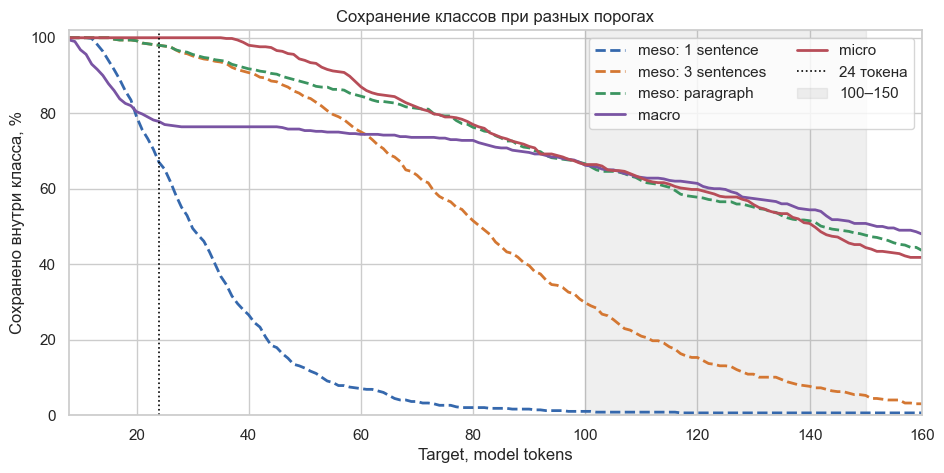

In [ ]:
records = []
for scenario in SCENARIOS:
    group = lengths[lengths['scenario'] == scenario]
    for target in TARGETS:
        eligible = group[group['model_token_count'] >= target]
        counts = eligible['label'].value_counts()
        cells = pd.crosstab(eligible['domain'], eligible['label']).reindex(index=['nlp', 'cv'], columns=LABELS, fill_value=0)
        records.append({
            'scenario': scenario, 'target': target,
            **{label: int(counts.get(label, 0)) for label in LABELS},
            'balanced_total': int(3 * cells.min(axis=1).sum()),
            'nlp_min_class': int(cells.loc['nlp'].min()),
            'cv_min_class': int(cells.loc['cv'].min()),
        })
retention = pd.DataFrame(records)
display(retention.set_index(['scenario', 'target']))

fig, ax = plt.subplots(figsize=(11, 5))
grid = np.arange(8, 161)
for scenario, title in [('first_sentence', 'meso: 1 sentence'),
                        ('first_three_sentences', 'meso: 3 sentences'),
                        ('first_paragraph', 'meso: paragraph')]:
    values = meso_lengths.loc[meso_lengths['scenario'] == scenario, 'model_token_count'].to_numpy()
    ax.plot(grid, [(values >= target).mean() * 100 for target in grid],
            label=title, color=palette[title], lw=2, ls='--')
for label in ['macro', 'micro']:
    values = reference.loc[reference['label'] == label, 'model_token_count'].to_numpy()
    ax.plot(grid, [(values >= target).mean() * 100 for target in grid],
            label=label, color=palette[label], lw=2, ls='-')
ax.axvline(SELECTED_LENGTH, color='black', ls=':', lw=1.2, label='24 токена')
ax.axvspan(100, 150, color='grey', alpha=.12, label='100–150')
ax.set(title='Сохранение классов при разных порогах', xlabel='Target, model tokens',
       ylabel='Сохранено внутри класса, %', xlim=(8, 160), ylim=(0, 102))
ax.legend(ncol=2)
plt.show()

## Как читать результат

Сравнение выше проводится на одних и тех же исходных примерах и показывает, меняется ли выбор допустимой длины при расширении `meso`. Более длинный текст может включать контекст, которого не было в первом предложении; поэтому изменение последующего F1 нельзя будет приписать только длине. Классификатор и эмбеддинги для этих двух новых вариантов здесь ещё не пересчитывались.